In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.1 MB/s eta 0:00:00


Using device: cuda
Events: 14671 | Objects: 9054
Train events: 10270 | Test events: 4401
Epoch   0 | loss=0.4989 | pos=0.257 | neg=0.256 | gap=0.001
Epoch  20 | loss=0.2778 | pos=0.532 | neg=0.306 | gap=0.226
Epoch  40 | loss=0.1705 | pos=0.627 | neg=0.264 | gap=0.362
Epoch  60 | loss=0.1276 | pos=0.678 | neg=0.246 | gap=0.432
Epoch  80 | loss=0.1076 | pos=0.711 | neg=0.243 | gap=0.468
Epoch 100 | loss=0.0865 | pos=0.740 | neg=0.237 | gap=0.503
Epoch 120 | loss=0.0735 | pos=0.760 | neg=0.224 | gap=0.536
Epoch 140 | loss=0.0720 | pos=0.767 | neg=0.224 | gap=0.543
Epoch 160 | loss=0.0661 | pos=0.770 | neg=0.217 | gap=0.553
Epoch 180 | loss=0.0576 | pos=0.783 | neg=0.209 | gap=0.574
Epoch 200 | loss=0.0560 | pos=0.791 | neg=0.210 | gap=0.581
Epoch 220 | loss=0.0489 | pos=0.793 | neg=0.197 | gap=0.596
Epoch 240 | loss=0.0446 | pos=0.806 | neg=0.200 | gap=0.606
Epoch 260 | loss=0.0483 | pos=0.798 | neg=0.196 | gap=0.602
Epoch 280 | loss=0.0500 | pos=0.799 | neg=0.198 | gap=0.601
Epoch 300 |

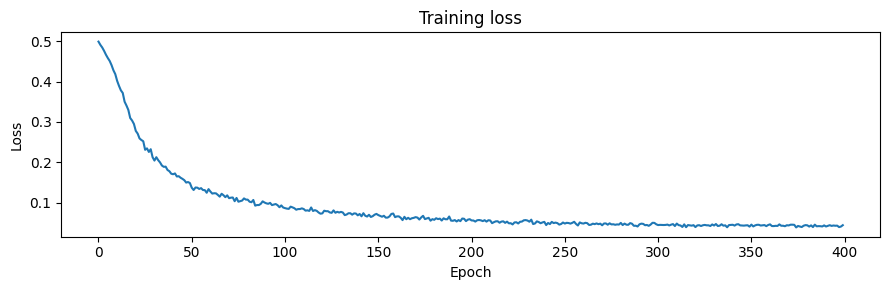


=== Train evaluation ===
  Evaluated on 200 samples
  Hits@1  : 0.5150  (103/200)
  Hits@5  : 0.7450  (149/200)
  Hits@10 : 0.8200  (164/200)
  MRR     : 0.6238

=== Test evaluation ===
  Evaluated on 200 samples
  Hits@1  : 0.4950  (99/200)
  Hits@5  : 0.6850  (137/200)
  Hits@10 : 0.7750  (155/200)
  MRR     : 0.5865


In [ ]:
import pandas as pd
import sqlite3
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# LOAD DATA
# =========================
#sqlite_path = "/content/drive/MyDrive/DSLab/ocel2-p2p_base.sqlite"
sqlite_path = Path(__file__).resolve().parent / "data" / "ocel2-p2p.sqlite"

conn = sqlite3.connect(sqlite_path)

event_object = pd.read_sql("SELECT ocel_event_id, ocel_object_id FROM event_object", conn)
object_rel   = pd.read_sql("SELECT ocel_source_id, ocel_target_id FROM object_object", conn)
event_table  = pd.read_sql("SELECT ocel_id, ocel_type FROM event", conn)
object_table = pd.read_sql("SELECT ocel_id, ocel_type FROM object", conn)

conn.close()

# =========================
# PREPROCESS
# =========================
event_df = (
    event_object
    .groupby("ocel_event_id")["ocel_object_id"]
    .apply(set)
    .reset_index()
)
event_df.columns = ["event_id", "objects"]

# Keep only events with at least 2 objects
event_df = event_df[event_df["objects"].apply(len) >= 2].reset_index(drop=True)

train_df = event_df.sample(frac=0.7, random_state=42)
test_df  = event_df.drop(train_df.index)

event_ids  = event_object["ocel_event_id"].unique()
object_ids = event_object["ocel_object_id"].unique()

event_map      = {e: i for i, e in enumerate(event_ids)}
object_map     = {o: i for i, o in enumerate(object_ids)}
inv_object_map = {v: k for k, v in object_map.items()}

print(f"Events: {len(event_map)} | Objects: {len(object_map)}")
print(f"Train events: {len(train_df)} | Test events: {len(test_df)}")

# =========================
# TYPE FEATURES  (vectorised)
# =========================
event_types    = event_table["ocel_type"].unique()
event_type_map = {t: i for i, t in enumerate(event_types)}

object_types    = object_table["ocel_type"].unique()
object_type_map = {t: i for i, t in enumerate(object_types)}

# Event type tensor
event_table["_eidx"] = event_table["ocel_id"].map(event_map)
event_table["_tidx"] = event_table["ocel_type"].map(event_type_map)
ev = event_table.dropna(subset=["_eidx", "_tidx"])

event_type_tensor = torch.zeros(len(event_map), dtype=torch.long)
event_type_tensor[ev["_eidx"].astype(int).values] = torch.tensor(
    ev["_tidx"].astype(int).values
)

# Object type tensor
object_table["_oidx"] = object_table["ocel_id"].map(object_map)
object_table["_tidx"] = object_table["ocel_type"].map(object_type_map)
ob = object_table.dropna(subset=["_oidx", "_tidx"])

object_type_tensor = torch.zeros(len(object_map), dtype=torch.long)
object_type_tensor[ob["_oidx"].astype(int).values] = torch.tensor(
    ob["_tidx"].astype(int).values
)

event_type_tensor  = event_type_tensor.to(device)
object_type_tensor = object_type_tensor.to(device)

# =========================
# HARD-NEGATIVE INDEX
# same-type negatives: object_type -> list of object indices
# =========================
type_to_object_indices = {}
for obj_id, obj_idx in object_map.items():
    t = object_type_tensor[obj_idx].item()
    type_to_object_indices.setdefault(t, []).append(obj_idx)

type_to_object_tensors = {
    t: torch.tensor(idxs) for t, idxs in type_to_object_indices.items()
}

# =========================
# BUILD GRAPH  (vectorised)
# =========================
data = HeteroData()
data["event"].num_nodes  = len(event_map)
data["object"].num_nodes = len(object_map)

# event -> object
eo = event_object.copy()
eo["src"] = eo["ocel_event_id"].map(event_map)
eo["dst"] = eo["ocel_object_id"].map(object_map)
eo = eo.dropna(subset=["src", "dst"])
src_t = torch.tensor(eo["src"].astype(int).values)
dst_t = torch.tensor(eo["dst"].astype(int).values)

data["event",  "has",     "object"].edge_index = torch.stack([src_t, dst_t])
data["object", "in",      "event"].edge_index  = torch.stack([dst_t, src_t])

# object -> object
oo = object_rel.copy()
oo["src"] = oo["ocel_source_id"].map(object_map)
oo["dst"] = oo["ocel_target_id"].map(object_map)
oo = oo.dropna(subset=["src", "dst"])
src_o = torch.tensor(oo["src"].astype(int).values)
dst_o = torch.tensor(oo["dst"].astype(int).values)

data["object", "related", "object"].edge_index = torch.stack([src_o, dst_o])

data = data.to(device)

# =========================
# MODEL  (3-layer HeteroGNN)
# =========================
class HeteroGNN(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.emb_event_type  = nn.Embedding(len(event_type_map),  hidden_dim)
        self.emb_object_id   = nn.Embedding(len(object_map),      hidden_dim)
        self.emb_object_type = nn.Embedding(len(object_type_map), hidden_dim)

        def make_conv():
            return HeteroConv({
                ("event",  "has",     "object"): SAGEConv((-1, -1), hidden_dim),
                ("object", "in",      "event"):  SAGEConv((-1, -1), hidden_dim),
                ("object", "related", "object"): SAGEConv((-1, -1), hidden_dim),
            }, aggr="sum")

        self.conv1   = make_conv()
        self.conv2   = make_conv()
        self.conv3   = make_conv()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, data):
        x_dict = {
            "event":  self.emb_event_type(event_type_tensor),
            "object": self.emb_object_id.weight + self.emb_object_type(object_type_tensor),
        }

        x_dict = self.conv1(x_dict, data.edge_index_dict)
        x_dict = {k: self.dropout(F.relu(x)) for k, x in x_dict.items()}

        x_dict = self.conv2(x_dict, data.edge_index_dict)
        x_dict = {k: self.dropout(F.relu(x)) for k, x in x_dict.items()}

        x_dict = self.conv3(x_dict, data.edge_index_dict)
        x_dict = {k: F.relu(x) for k, x in x_dict.items()}

        return x_dict


HIDDEN_DIM = 128
EPOCHS     = 400
BATCH_SIZE = 1024
MARGIN     = 0.5

model     = HeteroGNN(HIDDEN_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)

# =========================
# TRAINING  (multi-positive)
# Every linked object of an event is used as a positive,
# each paired with a same-type hard negative.
# =========================
losses = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    z = model(data)

    pos_e, pos_o, neg_o = [], [], []

    sampled = train_df.sample(n=min(BATCH_SIZE, len(train_df)), replace=True)

    for _, row in sampled.iterrows():
        objs = list(row["objects"])
        if len(objs) < 2:
            continue

        e = event_map[row["event_id"]]

        # All objects linked to this event are treated as positives
        for target in objs:
            if target not in object_map:
                continue
            o_pos = object_map[target]

            # Hard negative: same object type, different instance
            pos_type   = object_type_tensor[o_pos].item()
            candidates = type_to_object_tensors[pos_type]

            if len(candidates) < 2:
                # Only one object of this type — fall back to random
                o_neg = random.randint(0, len(object_map) - 1)
            else:
                for _ in range(5):
                    o_neg = candidates[torch.randint(len(candidates), (1,)).item()].item()
                    if o_neg != o_pos:
                        break

            pos_e.append(e)
            pos_o.append(o_pos)
            neg_o.append(o_neg)

    if len(pos_e) == 0:
        continue

    pos_e = torch.tensor(pos_e, device=device)
    pos_o = torch.tensor(pos_o, device=device)
    neg_o = torch.tensor(neg_o, device=device)

    e_emb   = F.normalize(z["event"][pos_e],  dim=-1)
    pos_emb = F.normalize(z["object"][pos_o], dim=-1)
    neg_emb = F.normalize(z["object"][neg_o], dim=-1)

    pos_score = (e_emb * pos_emb).sum(dim=-1)
    neg_score = (e_emb * neg_emb).sum(dim=-1)

    loss = F.relu(MARGIN - (pos_score - neg_score)).mean()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:>3} | loss={loss.item():.4f} "
            f"| pos={pos_score.mean():.3f} "
            f"| neg={neg_score.mean():.3f} "
            f"| gap={(pos_score - neg_score).mean():.3f}"
        )

# =========================
# PLOT LOSS
# =========================
plt.figure(figsize=(9, 3))
plt.plot(losses)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

# =========================
# SCORING HELPER
# =========================
def get_scores(z, event_id, observed_objects, o_embs):
    e      = event_map[event_id]
    e_emb  = F.normalize(z["event"][e].unsqueeze(0), dim=-1)
    scores = torch.matmul(e_emb, o_embs.T).squeeze()

    for o in observed_objects:
        if o in object_map:
            scores[object_map[o]] = -1.0

    return scores


def predict_single(event_id, observed_objects):
    model.eval()
    with torch.no_grad():
        z      = model(data)
        o_embs = F.normalize(z["object"], dim=-1)
        scores = get_scores(z, event_id, observed_objects, o_embs)
    best = torch.argmax(scores).item()
    return inv_object_map[best], scores[best].item()


# =========================
# EVALUATION  — Hits@K + MRR
# Embeddings computed once and reused across all samples
# =========================
def evaluate(df, k_values=(1, 5, 10), n_samples=200):
    model.eval()

    hits   = {k: 0 for k in k_values}
    rr_sum = 0.0
    total  = 0

    sample = df.sample(n=min(n_samples, len(df)), random_state=0)

    with torch.no_grad():
        z      = model(data)
        o_embs = F.normalize(z["object"], dim=-1)

    for _, row in sample.iterrows():
        objs = list(row["objects"])
        if len(objs) < 2:
            continue

        target   = random.choice(objs)
        observed = [o for o in objs if o != target]

        if target not in object_map:
            continue

        target_idx = object_map[target]

        with torch.no_grad():
            scores = get_scores(z, row["event_id"], observed, o_embs)

        rank = (scores > scores[target_idx]).sum().item() + 1  # 1-indexed

        for k in k_values:
            if rank <= k:
                hits[k] += 1

        rr_sum += 1.0 / rank
        total  += 1

    if total == 0:
        print("No valid samples.")
        return

    print(f"  Evaluated on {total} samples")
    for k in k_values:
        print(f"  Hits@{k:<3}: {hits[k]/total:.4f}  ({hits[k]}/{total})")
    print(f"  MRR     : {rr_sum/total:.4f}")


print("\n=== Train evaluation ===")
evaluate(train_df)

print("\n=== Test evaluation ===")
evaluate(test_df)

In [ ]:
import pandas as pd
import torch
import torch.nn.functional as F
import random

# =========================
# TOP-K EXPLANATION VIEWER
# =========================
def explain_prediction(
    model,
    data,
    df,
    event_map,
    object_map,
    inv_object_map,
    k=5,
    n_samples=10
):

    model.eval()

    samples = df.sample(n=min(n_samples, len(df)), random_state=42)

    with torch.no_grad():
        z = model(data)
        obj_embs = F.normalize(z["object"], dim=-1)

    print("\n" + "=" * 80)
    print("OCEL GAP RECONSTRUCTION - EXPLANATION VIEW")
    print("=" * 80)

    for i, (_, row) in enumerate(samples.iterrows()):

        objs = list(row["objects"])
        if len(objs) < 2:
            continue

        # pick target missing object
        target = random.choice(objs)
        observed = [o for o in objs if o != target]

        if target not in object_map:
            continue

        e_idx = event_map[row["event_id"]]

        # event embedding
        e_emb = F.normalize(z["event"][e_idx].unsqueeze(0), dim=-1)

        # scores
        scores = torch.matmul(e_emb, obj_embs.T).squeeze(0)

        # mask observed objects
        for o in observed:
            if o in object_map:
                scores[object_map[o]] = -1e9

        # top-k predictions
        topk_scores, topk_idx = torch.topk(scores, k)

        pred = topk_idx[0].item()
        true_idx = object_map[target]

        print(f"\n🧩 SAMPLE {i+1}")
        print("-" * 60)

        print(f"Event ID: {row['event_id']}")
        print(f"Observed objects ({len(observed)}):")
        print([inv_object_map[object_map[o]] for o in observed if o in object_map])

        print(f"\n🎯 TRUE missing object:")
        print(inv_object_map[true_idx])

        print(f"\n🏆 TOP-{k} predictions:")

        for rank, (idx, score) in enumerate(zip(topk_idx, topk_scores)):
            obj_name = inv_object_map[idx.item()]
            is_true = "✅" if idx.item() == true_idx else ""
            print(f"{rank+1:>2}. {obj_name:<30} score={score.item():.4f} {is_true}")

        print(f"\n📌 FINAL PREDICTION:")
        print(inv_object_map[pred])

        print(f"RESULT: {'✅ CORRECT' if pred == true_idx else '❌ WRONG'}")

        print("=" * 60)

explain_prediction(
    model=model,
    data=data,
    df=test_df,
    event_map=event_map,
    object_map=object_map,
    inv_object_map=inv_object_map,
    k=5,
    n_samples=10
)


OCEL GAP RECONSTRUCTION - EXPLANATION VIEW

🧩 SAMPLE 1
------------------------------------------------------------
Event ID: event:11748
Observed objects (1):
['quotation:380']

🎯 TRUE missing object:
purchase_order:646

🏆 TOP-5 predictions:
 1. goods receipt:1501             score=0.9037 
 2. purchase_order:646             score=0.8808 ✅
 3. invoice receipt:760            score=0.8347 
 4. invoice receipt:405            score=0.8309 
 5. purchase_requisition:779:pr_trigger_779 score=0.8121 

📌 FINAL PREDICTION:
goods receipt:1501
RESULT: ❌ WRONG

🧩 SAMPLE 2
------------------------------------------------------------
Event ID: event:4352
Observed objects (1):
['goods receipt:249']

🎯 TRUE missing object:
invoice receipt:262

🏆 TOP-5 predictions:
 1. invoice receipt:262            score=0.9662 ✅
 2. goods receipt:310              score=0.9228 
 3. purchase_order:1281            score=0.9140 
 4. invoice receipt:68             score=0.8784 
 5. purchase_order:333             score=0.8